# Solving a Real Physics PDE: The 2D Heat Equation

This notebook solves the two-dimensional heat equation

$$\frac{\partial u}{\partial t} = \kappa \Delta u$$

on the unit square with homogeneous Dirichlet boundary conditions. After finite-difference discretization, the solution is a matrix function

$$u(t) = e^{-\kappa t L}u(0),$$

where `L` is the positive semidefinite 2D negative Laplacian. We approximate this heat semigroup with a bounded exponential-like polynomial on a rescaled spectrum, which is the type of spectral transform a QSVT workflow targets after block encoding.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a two-dimensional heat equation on a unit square with homogeneous Dirichlet boundaries.

**QSVT implementation.** It approximates the heat semigroup with a polynomial of the rescaled 2D Laplacian. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral heat flow validates the field and residual. The quantum-algorithmic relevance is applying parabolic PDE matrix functions to large sparse grids through block encodings rather than explicit eigenbasis construction.


## Variable definitions

- `nx`, `ny`: interior grid dimensions.
- `kappa`: heat diffusivity.
- `time`: evolution time.
- `x`, `y`, `L`: 2D grid coordinates and Dirichlet negative-Laplacian matrix.
- `eigenvalues`: eigenvalues of `L`.
- `grid_x`, `grid_y`, `X`, `Y`: meshgrids for plotting and initial data.
- `u0`, `u0_vec`: initial heat field and flattened vector form.
- `lambda_min`, `lambda_max`: smallest and largest Laplacian eigenvalues.
- `center`, `half_width`: midpoint and half-width of the spectrum.
- `A`: rescaled Laplacian.
- `beta`: scaled heat-semigroup strength.
- `prefactor`: scalar restoring the physical heat-semigroup normalization.
- `coeffs`: exponential polynomial coefficients.
- `u_poly_vec`, `u_exact_vec`: flattened polynomial and exact heat-evolved fields.
- `relative_error`: relative field error.
- `u_poly`, `u_exact`, `difference`: reshaped fields and their difference.
- `fig`, `axes`, `fields`, `titles`, `cmaps`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.pde import dirichlet_laplacian_2d
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

## Discretize the PDE

The 2D negative Laplacian is built as a Kronecker sum of 1D Dirichlet Laplacians. With zero boundary values, the interior grid satisfies

$$\frac{d u}{dt} = -\kappa L u.$$

In [2]:
nx = 10
ny = 10
kappa = 0.01
time = 0.06

x, y, L = dirichlet_laplacian_2d(nx, ny)
eigenvalues, _ = eigh_hermitian(L)

print(f"First 5 Eigenvalues [inverse grid-length units]: {eigenvalues[:5]}")
print(f"Last Eigenvalue [inverse grid-length units]: {eigenvalues[-1]}")
print(f"Matrix Shape [rows, cols]: {L.shape}")

First 5 Eigenvalues [inverse grid-length units]: [19.6054 48.2193 48.2193 76.8333 93.3264]
Last Eigenvalue [inverse grid-length units]: 948.3945992294168
Matrix Shape [rows, cols]: (100, 100)


## Domain and boundary conditions

The heat equation is solved on the interior grid of a unit square with homogeneous Dirichlet temperature on every boundary.


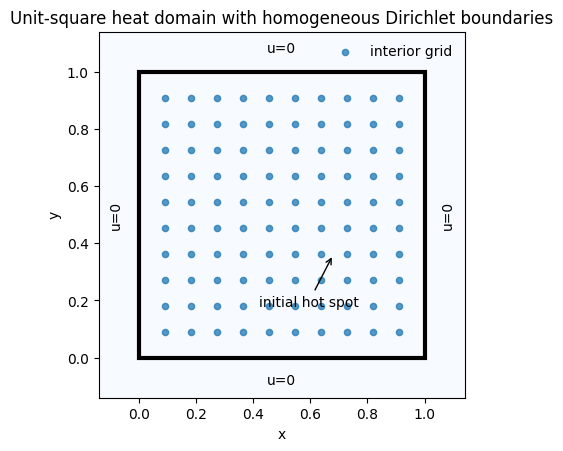

In [3]:
fig, ax = plt.subplots(figsize=(4.6, 4.4), constrained_layout=True)

ax.set_facecolor("#f7fbff")
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, linewidth=3.0, edgecolor="black"))
for xpos, ypos, rotation, label in [
    (0.5, -0.08, 0, "u=0"),
    (0.5, 1.08, 0, "u=0"),
    (-0.08, 0.5, 90, "u=0"),
    (1.08, 0.5, 90, "u=0"),
]:
    ax.text(xpos, ypos, label, ha="center", va="center", rotation=rotation)

grid_x, grid_y = np.meshgrid(x, y, indexing="ij")
ax.scatter(
    grid_x.ravel(),
    grid_y.ravel(),
    s=20,
    color="tab:blue",
    alpha=0.75,
    label="interior grid",
)
ax.annotate(
    "initial hot spot",
    xy=(0.68, 0.36),
    xytext=(0.42, 0.18),
    arrowprops={"arrowstyle": "->"},
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Unit-square heat domain with homogeneous Dirichlet boundaries")
ax.set_xlim(-0.14, 1.14)
ax.set_ylim(-0.14, 1.14)
ax.set_aspect("equal")
ax.legend(loc="upper right", frameon=False)
plt.show()

## Initial temperature field

The initial condition combines a smooth low-frequency standing mode with an off-center hot spot. Heat flow damps the localized feature faster than the broad mode.

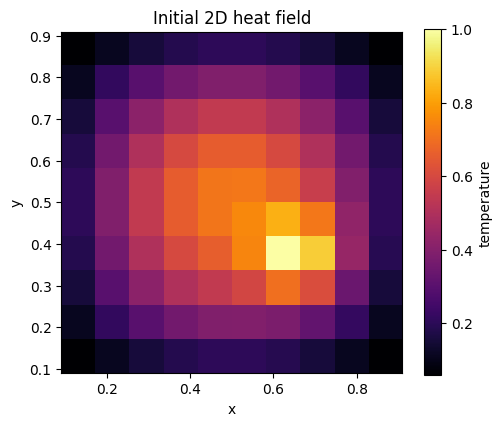

In [4]:
X, Y = np.meshgrid(x, y, indexing="ij")

u0 = np.sin(np.pi * X) * np.sin(np.pi * Y)
u0 += 0.65 * np.exp(-90.0 * ((X - 0.68) ** 2 + (Y - 0.36) ** 2))
u0 = u0 / np.max(np.abs(u0))
u0_vec = u0.reshape(-1)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(
    u0.T,
    origin="lower",
    extent=[x[0], x[-1], y[0], y[-1]],
    cmap="inferno",
    aspect="equal",
)
plt.colorbar(label="temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial 2D heat field")
plt.show()

## Rescale the Laplacian to `[-1, 1]`

The heat operator `exp(-kappa * time * L)` decreases with increasing Laplacian eigenvalue. Map the smallest eigenvalue to `+1` and the largest to `-1`:

$$A = \frac{cI - L}{h}, \qquad c=\frac{\lambda_{\min}+\lambda_{\max}}{2}, \quad h=\frac{\lambda_{\max}-\lambda_{\min}}{2}.$$

Then

$$e^{-\kappa t L} = e^{-\kappa t c + \beta}\,p(A), \qquad \beta=\kappa t h,$$

where `p(x)` approximates `exp(beta*x - beta)` and remains bounded by one on `[-1, 1]`.

In [5]:
lambda_min = eigenvalues[0]
lambda_max = eigenvalues[-1]
center = 0.5 * (lambda_min + lambda_max)
half_width = 0.5 * (lambda_max - lambda_min)

A = (center * np.eye(nx * ny) - L) / half_width
beta = kappa * time * half_width
prefactor = np.exp(-kappa * time * center + beta)

print(f"First Eigenvalue [model spectral units]: {np.linalg.eigvalsh(A)[0]}")
print(f"Last Eigenvalue [model spectral units]: {np.linalg.eigvalsh(A)[-1]}")
print(f"Beta: {beta}")
print(f"Prefactor: {prefactor}")

First Eigenvalue [model spectral units]: -1.0000000000000009
Last Eigenvalue [model spectral units]: 1.000000000000001
Beta: 0.27863675953765005
Prefactor: 0.9883056759592374


## Polynomial heat step

Apply the polynomial approximation to the rescaled operator and compare it with exact diagonalization of the finite-difference heat operator.

In [6]:
degree = 16
coeffs = exponential_approximation_polynomial(degree=degree, beta=beta)

u_poly_vec = prefactor * (apply_polynomial_to_hermitian(A, coeffs) @ u0_vec)
u_exact_vec = (
    apply_function_to_hermitian(
        L,
        lambda lam: np.exp(-kappa * time * lam),
    )
    @ u0_vec
)

relative_error = np.linalg.norm(u_poly_vec - u_exact_vec) / np.linalg.norm(u_exact_vec)
print(f"Relative Error: {relative_error}")

Relative Error: 4.054746215837559e-13


The polynomial degree is intentionally modest because this is a small educational grid. The approximation is already accurate for the chosen time step because the rescaled heat profile is smooth and bounded.

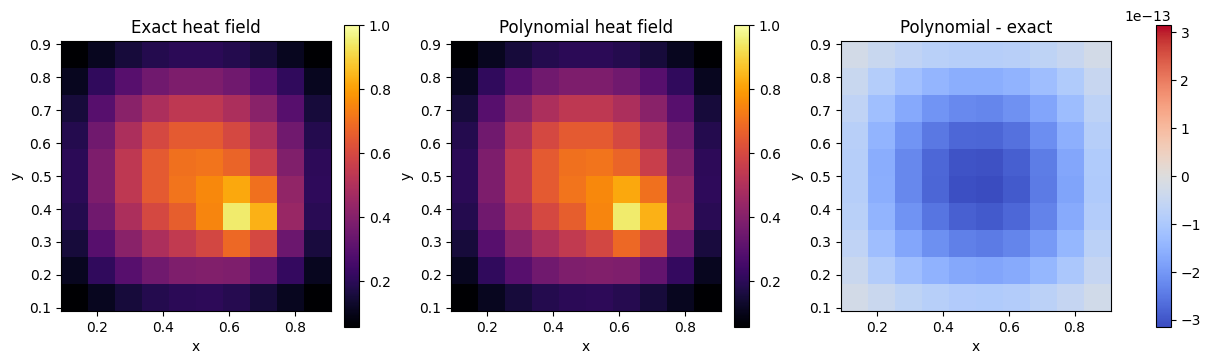

In [7]:
u_poly = u_poly_vec.reshape(nx, ny)
u_exact = u_exact_vec.reshape(nx, ny)
difference = u_poly - u_exact

vmin = min(u0.min(), u_exact.min(), u_poly.min())
vmax = max(u0.max(), u_exact.max(), u_poly.max())

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
fields = [u_exact, u_poly, difference]
titles = ["Exact heat field", "Polynomial heat field", "Polynomial - exact"]
cmaps = ["inferno", "inferno", "coolwarm"]

for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    if title == "Polynomial - exact":
        scale = np.max(np.abs(field))
        image = ax.imshow(
            field.T,
            origin="lower",
            extent=[x[0], x[-1], y[0], y[-1]],
            cmap=cmap,
            vmin=-scale,
            vmax=scale,
            aspect="equal",
        )
    else:
        image = ax.imshow(
            field.T,
            origin="lower",
            extent=[x[0], x[-1], y[0], y[-1]],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(image, ax=ax, shrink=0.82)

plt.show()

## Spectral damping profile

QSVT sees the PDE through the spectrum. This plot compares the exact heat damping factor with the polynomial approximation on the rescaled eigenvalue interval.

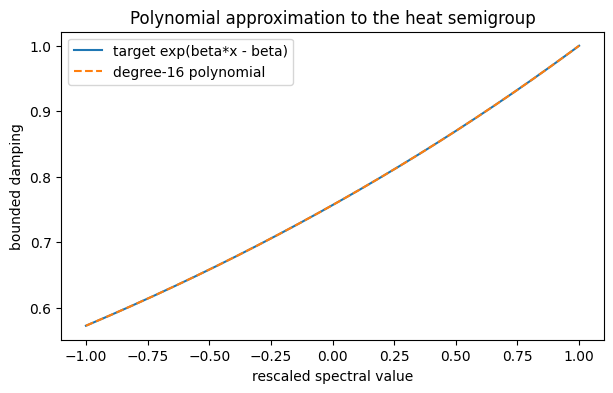

Maximum Approximation Error: 4.127809205556332e-13


In [8]:
xs = np.linspace(-1.0, 1.0, 500)
target = np.exp(beta * xs - beta)
approx = eval_polynomial(coeffs, xs)

plt.figure(figsize=(7, 4))
plt.plot(xs, target, label="target exp(beta*x - beta)")
plt.plot(xs, approx, "--", label=f"degree-{degree} polynomial")
plt.xlabel("rescaled spectral value")
plt.ylabel("bounded damping")
plt.title("Polynomial approximation to the heat semigroup")
plt.legend()
plt.show()

print(f"Maximum Approximation Error: {np.max(np.abs(target - approx))}")

## Validation

Compact checks for the expected numerical behavior.

In [9]:
assert np.isfinite(relative_error)
assert relative_error < 1e-8
assert u_poly.shape == u_exact.shape == u0.shape

print(f"relative_error: {relative_error:.3e}")
print(f"max_abs_difference [field units]: {np.max(np.abs(difference)):.3e}")
print("validation: passed")

relative_error: 4.055e-13
max_abs_difference [field units]: 3.149e-13
validation: passed
